# Exploratory Data Analysis: Streaming App Reviews

Notebook ini melakukan analisis eksploratif terhadap data review aplikasi streaming Indonesia (Netflix, Vidio, Disney+ Hotstar, WeTV, Viu).

## Pertanyaan yang Akan Dijawab:
1. Bagaimana distribusi rating per aplikasi?
2. Aplikasi mana yang paling banyak direview?
3. Bagaimana sentiment proportion antar aplikasi?
4. Kata apa yang paling sering muncul di review positif vs negatif?
5. Bagaimana trend rating over time?
6. Berapa panjang review yang ideal?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Setting visual yang cantik
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Custom color palette per app
app_colors = {
    'Netflix': '#E50914',
    'Vidio': '#0075FF',
    'Disney+ Hotstar': '#113CCF',
    'WeTV': '#FF6600',
    'Viu': '#FCD000'
}

sentiment_colors = {
    'positive': '#2ECC71',
    'neutral': '#95A5A6',
    'negative': '#E74C3C'
}

# Load data hasil preprocessing
df = pd.read_csv('../data/reviews_preprocessed.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"📦 Total reviews: {len(df):,}")
print(f"📅 Period: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\n📱 Apps: {df['app_name'].unique()}")
df.head()

📦 Total reviews: 9,305
📅 Period: 2025-07-10 → 2026-05-26

📱 Apps: <StringArray>
['Netflix', 'Vidio', 'Disney+ Hotstar', 'WeTV', 'Viu']
Length: 5, dtype: str


,app_name,username,rating,review,date,thumbs_up,review_length,review_clean,review_normalized,review_no_stopwords,review_stemmed,sentiment
0,Netflix,Oliv_mgrthh 29,3,"susah masuk kedalam akun, selalu terlalu banya...",2026-05-26 20:19:03,0,53,susah masuk kedalam akun selalu terlalu banyak...,susah masuk kedalam akun selalu terlalu banyak...,susah masuk kedalam akun selalu terlalu banyak...,susah masuk dalam akun selalu terlalu banyak u...,neutral
1,Netflix,Fina Nazilia,1,"tidak bisa masuk, harus berbayar dahulu",2026-05-26 20:00:02,0,39,tidak bisa masuk harus berbayar dahulu,tidak bisa masuk harus berbayar dahulu,tidak masuk berbayar,tidak masuk bayar,negative
2,Netflix,Bayu Gustiawan,1,Daftar ae dibikin muter muter,2026-05-26 18:58:22,0,29,daftar ae dibikin muter muter,daftar ae dibikin muter muter,daftar ae dibikin muter muter,daftar ae bikin muter muter,negative
3,Netflix,Luh Gian Adinda,4,"harry potter,please",2026-05-26 17:20:46,0,19,harry potter please,harry potter please,harry potter please,harry potter please,positive
4,Netflix,Rahma,1,sdah berlangganan dan bayar tpi tiap mau masuk...,2026-05-26 15:52:44,0,112,sdah berlangganan dan bayar tpi tiap mau masuk...,sdah berlangganan dan bayar tapi tiap mau masu...,sdah berlangganan bayar tiap mau masuk sandi s...,sdah langgan bayar tiap mau masuk sandi sllu s...,negative


#### 1. Distribusi Review per Aplikasi

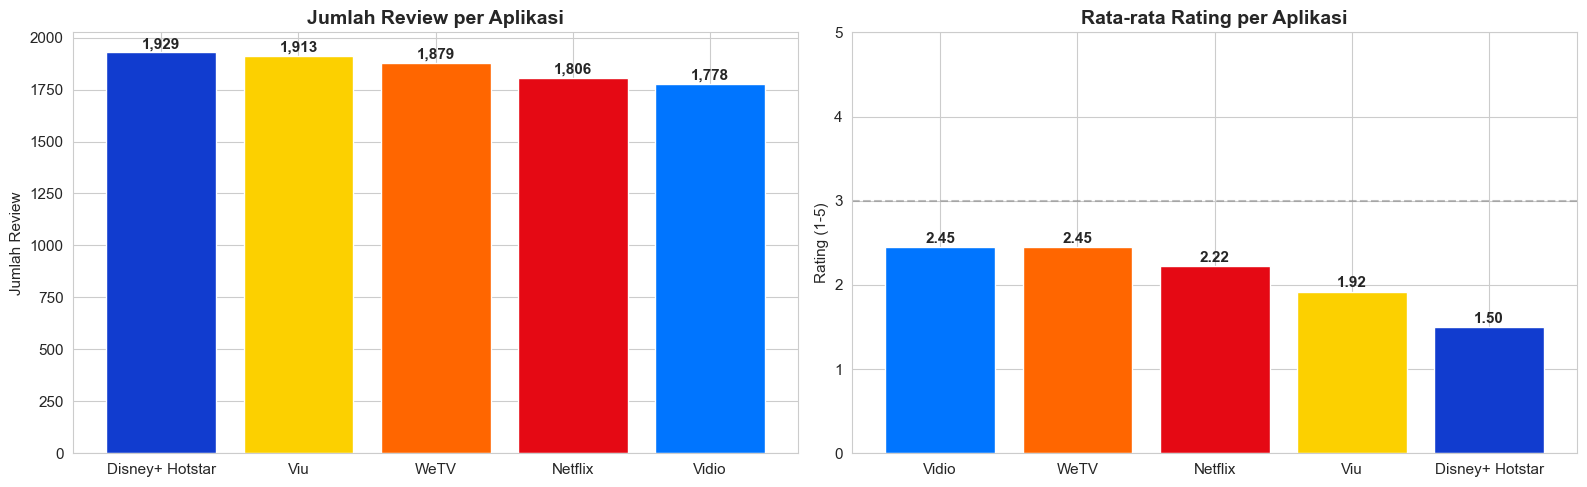


🏆 Insight:
  Aplikasi dengan review terbanyak: Disney+ Hotstar (1,929 reviews)
  Aplikasi dengan rating tertinggi: Vidio (2.45/5)
  Aplikasi dengan rating terendah: Disney+ Hotstar (1.50/5)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total review per app
app_counts = df['app_name'].value_counts()
bars = axes[0].bar(app_counts.index, app_counts.values,
                    color=[app_colors[app] for app in app_counts.index])
axes[0].set_title('Jumlah Review per Aplikasi', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Review')
axes[0].set_xlabel('')
for bar, val in zip(bars, app_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')

# Plot 2: Average rating per app
avg_rating = df.groupby('app_name')['rating'].mean().sort_values(ascending=False)
bars = axes[1].bar(avg_rating.index, avg_rating.values,
                    color=[app_colors[app] for app in avg_rating.index])
axes[1].set_title('Rata-rata Rating per Aplikasi', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rating (1-5)')
axes[1].set_ylim(0, 5)
axes[1].axhline(y=3, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, avg_rating.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 Insight:")
print(f"  Aplikasi dengan review terbanyak: {app_counts.idxmax()} ({app_counts.max():,} reviews)")
print(f"  Aplikasi dengan rating tertinggi: {avg_rating.idxmax()} ({avg_rating.max():.2f}/5)")
print(f"  Aplikasi dengan rating terendah: {avg_rating.idxmin()} ({avg_rating.min():.2f}/5)")

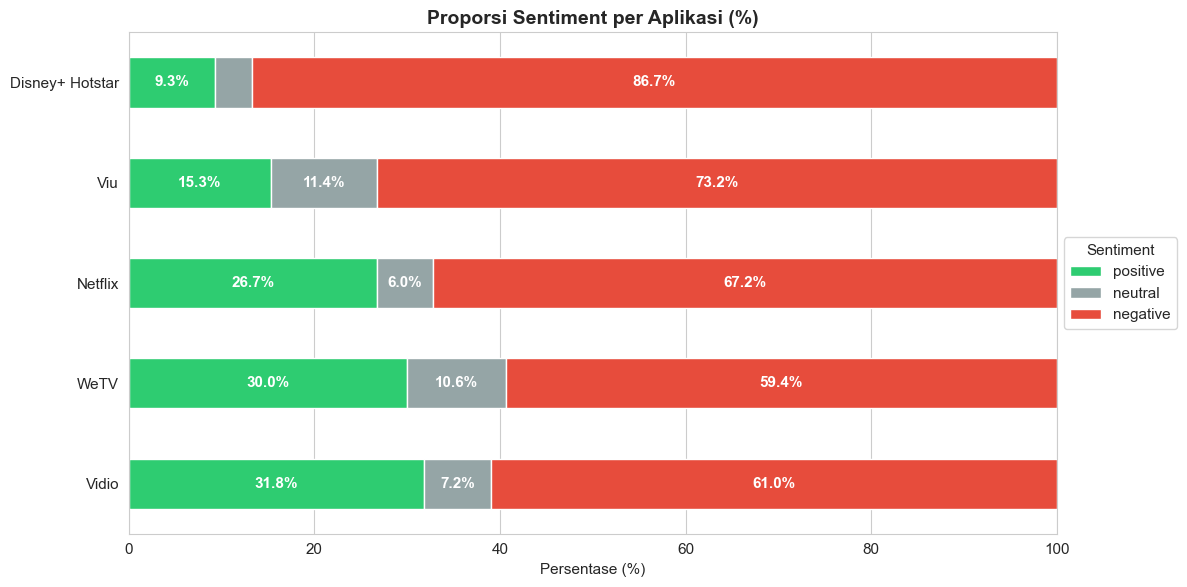


🏆 Insight:
  Sentiment positif tertinggi: Vidio (31.8%)
  Sentiment negatif tertinggi: Disney+ Hotstar (86.7%)


In [3]:
# Stacked bar: proporsi sentiment per app
sentiment_pct = df.groupby('app_name')['sentiment'].value_counts(normalize=True).unstack() * 100
sentiment_pct = sentiment_pct[['positive', 'neutral', 'negative']]  # urutan
sentiment_pct = sentiment_pct.sort_values('positive', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sentiment_pct.plot(kind='barh', stacked=True, ax=ax,
                    color=[sentiment_colors[s] for s in sentiment_pct.columns])
ax.set_title('Proporsi Sentiment per Aplikasi (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('')
ax.legend(title='Sentiment', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlim(0, 100)

# Tambah label persen di tiap segmen
for i, app in enumerate(sentiment_pct.index):
    cumulative = 0
    for sent in ['positive', 'neutral', 'negative']:
        val = sentiment_pct.loc[app, sent]
        if val > 5:  # Hanya tampilkan kalau >5% biar tidak crowded
            ax.text(cumulative + val/2, i, f'{val:.1f}%',
                   ha='center', va='center', fontweight='bold', color='white')
        cumulative += val

plt.tight_layout()
plt.show()

print("\n🏆 Insight:")
top_positive = sentiment_pct['positive'].idxmax()
top_negative = sentiment_pct['negative'].idxmax()
print(f"  Sentiment positif tertinggi: {top_positive} ({sentiment_pct['positive'].max():.1f}%)")
print(f"  Sentiment negatif tertinggi: {top_negative} ({sentiment_pct['negative'].max():.1f}%)")

#### 2. Word Cloud: Kata Paling Sering Muncul

Word cloud membantu kita lihat secara cepat kata apa yang dominan di review **positif** vs **negatif**.

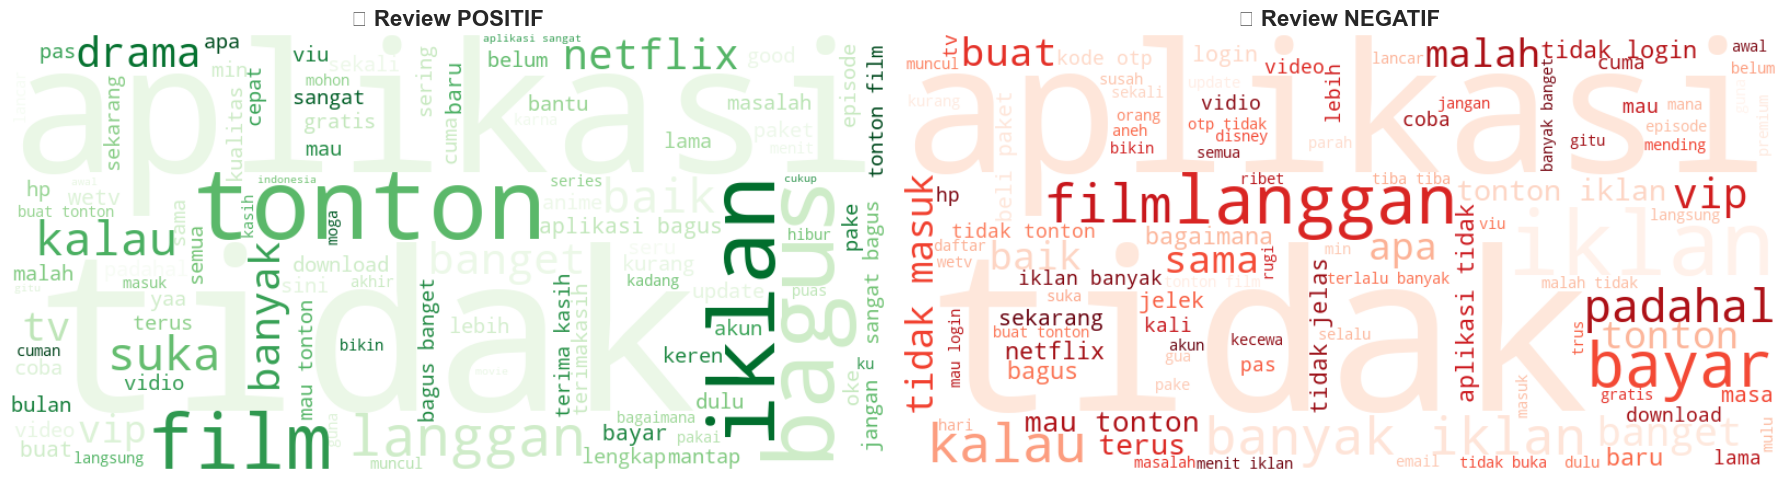

In [4]:
# Gabung semua text positif & negatif
text_positive = ' '.join(df[df['sentiment'] == 'positive']['review_stemmed'].dropna().astype(str))
text_negative = ' '.join(df[df['sentiment'] == 'negative']['review_stemmed'].dropna().astype(str))

# Buat 2 wordcloud
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Positif
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100, random_state=42).generate(text_positive)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('🟢 Review POSITIF', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Negatif
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100, random_state=42).generate(text_negative)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('🔴 Review NEGATIF', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

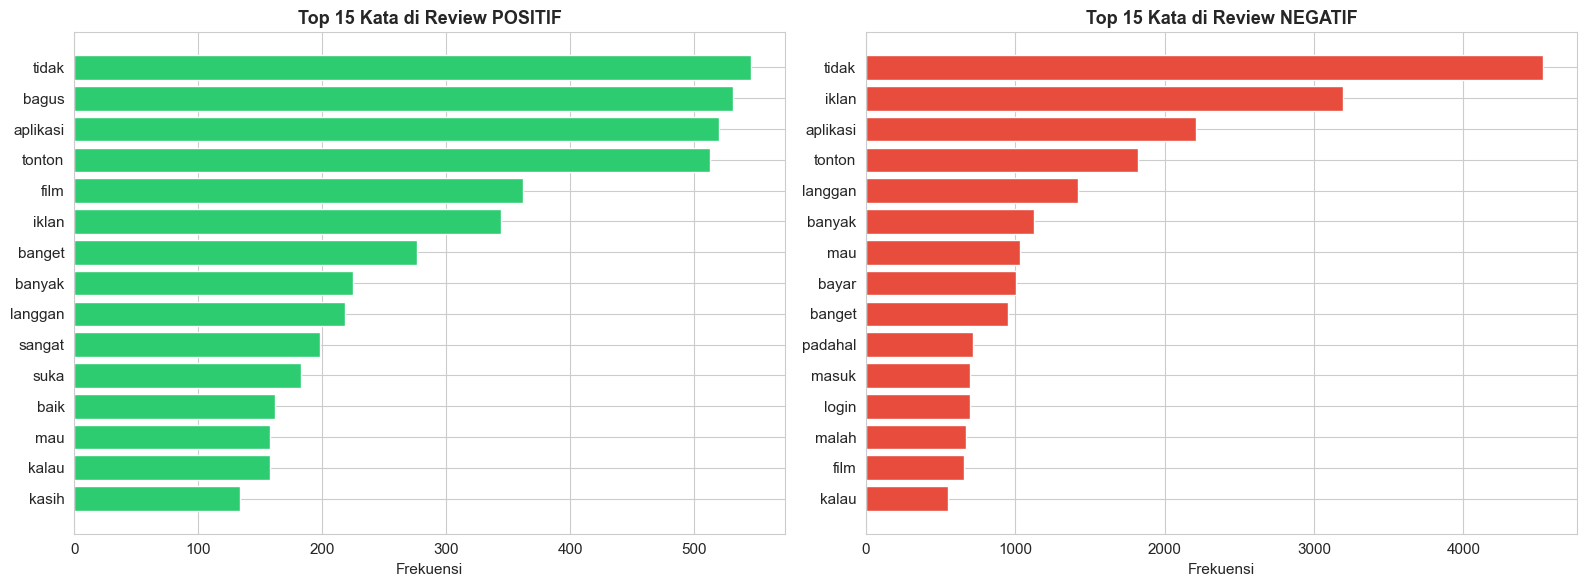


🎯 Kata-kata ini akan jadi 'fitur' penting untuk model sentiment nanti.


In [5]:
def get_top_words(texts, n=15):
    words = ' '.join(texts.dropna().astype(str)).split()
    return Counter(words).most_common(n)

top_pos = get_top_words(df[df['sentiment'] == 'positive']['review_stemmed'])
top_neg = get_top_words(df[df['sentiment'] == 'negative']['review_stemmed'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positif
words_p, counts_p = zip(*top_pos)
axes[0].barh(words_p[::-1], counts_p[::-1], color='#2ECC71')
axes[0].set_title('Top 15 Kata di Review POSITIF', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frekuensi')

# Negatif
words_n, counts_n = zip(*top_neg)
axes[1].barh(words_n[::-1], counts_n[::-1], color='#E74C3C')
axes[1].set_title('Top 15 Kata di Review NEGATIF', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

print("\n🎯 Kata-kata ini akan jadi 'fitur' penting untuk model sentiment nanti.")

#### 3. Trend Rating Over Time

Apakah rating berubah seiring waktu? Mungkin ada event tertentu (price increase, update buruk, dll) yang bikin sentiment turun drastis.

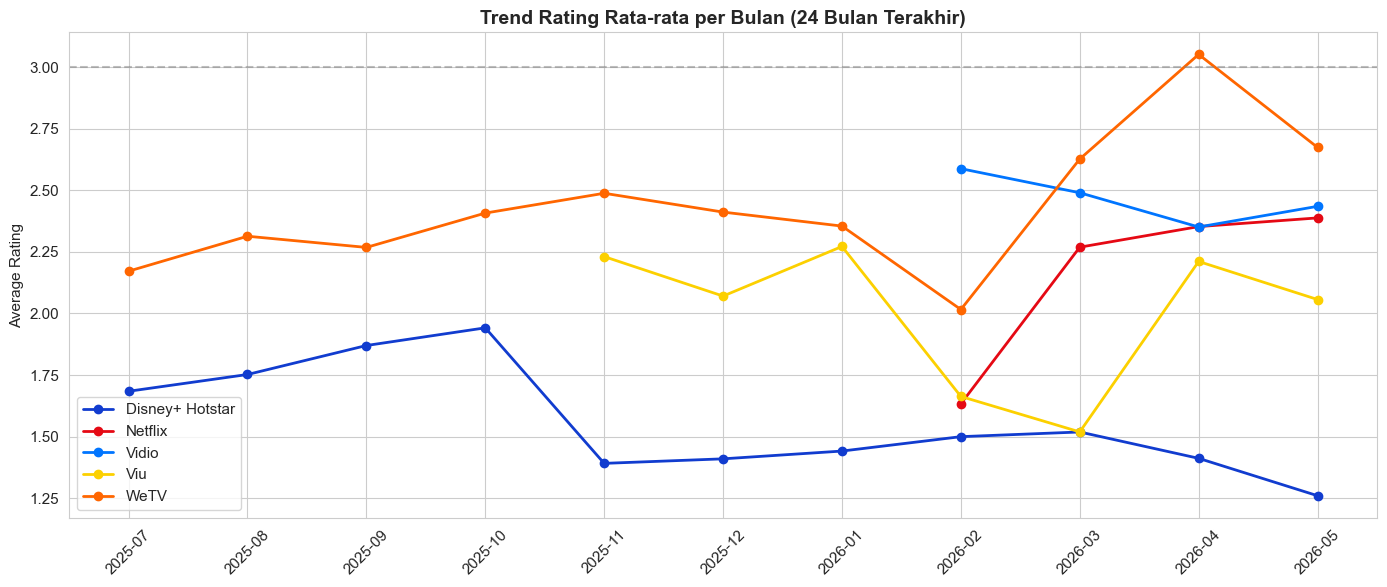


🔍 Cari pattern: apakah ada bulan dimana rating drop drastis?
   Itu mungkin tanda ada update buruk atau kebijakan kontroversial.


In [7]:
# Resample per bulan
df['year_month'] = df['date'].dt.to_period('M').astype(str)

monthly_rating = df.groupby(['year_month', 'app_name'])['rating'].mean().unstack()

# Hanya ambil 24 bulan terakhir biar tidak crowded
monthly_rating = monthly_rating.tail(24)

fig, ax = plt.subplots(figsize=(14, 6))
for app in monthly_rating.columns:
    ax.plot(monthly_rating.index, monthly_rating[app],
            marker='o', label=app, color=app_colors[app], linewidth=2)

ax.set_title('Trend Rating Rata-rata per Bulan (24 Bulan Terakhir)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Average Rating')
ax.set_xlabel('')
ax.legend(loc='lower left')
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n🔍 Cari pattern: apakah ada bulan dimana rating drop drastis?")
print("   Itu mungkin tanda ada update buruk atau kebijakan kontroversial.")

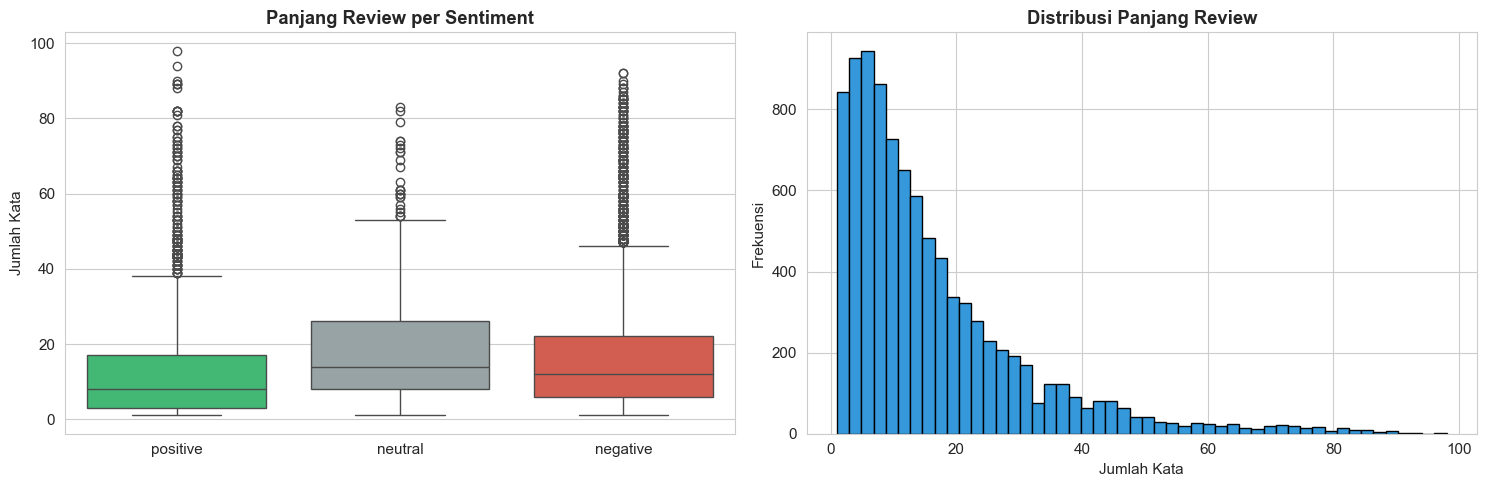


📊 Rata-rata panjang review:
sentiment
negative    16.8
neutral     19.0
positive    13.1
Name: word_count, dtype: float64

💡 Biasanya review negatif lebih panjang karena user mau curhat detail keluhannya.


In [8]:
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot panjang review per sentiment
sns.boxplot(data=df[df['word_count'] < 100], x='sentiment', y='word_count',
            ax=axes[0], palette=sentiment_colors,
            order=['positive', 'neutral', 'negative'])
axes[0].set_title('Panjang Review per Sentiment', fontweight='bold')
axes[0].set_ylabel('Jumlah Kata')
axes[0].set_xlabel('')

# Distribusi panjang review
df[df['word_count'] < 100]['word_count'].hist(bins=50, ax=axes[1], color='#3498DB', edgecolor='black')
axes[1].set_title('Distribusi Panjang Review', fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"\n📊 Rata-rata panjang review:")
print(df.groupby('sentiment')['word_count'].mean().round(1))
print("\n💡 Biasanya review negatif lebih panjang karena user mau curhat detail keluhannya.")

## Ringkasan Insight EDA

1. **Volume Review:** Disney+ Hotstar menerima review terbanyak (1,929), 
   menunjukkan basis user besar — tapi tidak diiringi kepuasan.

2. **Rating:** Semua aplikasi punya rata-rata rating < 3.0. Vidio tertinggi 
   (2.45), Disney+ Hotstar terendah (1.50).

3. **Sentiment Crisis di Disney+ Hotstar:** 86.7% review bernada negatif — 
   indikasi serius adanya masalah produk/layanan.

4. **Top 3 Keluhan Universal:**
   - **Iklan berlebihan** (3,200+ mentions di review negatif)
   - **Masalah login & OTP**
   - **Sistem berlangganan & pembayaran**

5. **Trend Notable:** 
   - Disney+ Hotstar drop drastis di Nov 2025 (perlu investigasi event)
   - WeTV menunjukkan perbaikan konsisten

6. **Behavior User:** Review negatif lebih panjang (median 13 kata) vs 
   positif (median 8 kata) — user kecewa cenderung curhat detail.

**Next Step:** Build sentiment classification model untuk auto-categorize 
review baru, lalu deep dive ke topic modeling untuk identify masalah spesifik 
per aplikasi.